In [ ]:
import joblib
import requests
import numpy as np
import pandas as pd
import rasterio
from rasterio.merge import merge
from scipy.ndimage import sobel
import matplotlib.pyplot as plt
import fiona

fiona.drvsupport.supported_drivers['KML'] = 'rw'

In [ ]:
src_north = rasterio.open("bng_north.tif")
src_south = rasterio.open("bng_south.tif")
nodata_val = src_north.nodata

elevation_matrix, elevation_transform = merge([src_north, src_south])
target_crs = src_north.crs.to_string()
target_height = elevation_matrix.shape[1]
target_width = elevation_matrix.shape[2]
src_north.close()
src_south.close()

elevation_grid = elevation_matrix[0].astype(np.float32)
if nodata_val is not None:
    elevation_grid[elevation_grid == nodata_val] = np.nan

slope_x = sobel(elevation_grid, axis=1)
slope_y = sobel(elevation_grid, axis=0)
slope = np.hypot(slope_x, slope_y)

print(f"Terrain loaded: {target_height}x{target_width}")

Terrain loaded: 7200x3600


In [ ]:
rf_model = joblib.load('flood_model1.pkl')
print("Model loaded successfully")

Model loaded successfully


In [ ]:
def get_bengaluru_forecast():
    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": 12.9716,
        "longitude": 77.5946,
        "daily": "precipitation_sum",
        "timezone": "Asia/Kolkata",
        "forecast_days": 3
    }
    data = requests.get(url, params=params).json()
    daily_rain = data['daily']['precipitation_sum']
    dates = data['daily']['time']

    total = sum(daily_rain)
    mean = np.mean(daily_rain)
    maximum = max(daily_rain)

    print("===== LIVE FORECAST (Next 3 Days) =====")
    for date, rain in zip(dates, daily_rain):
        print(f"{date}: {rain:.1f}mm")
    print(f"\nTotal: {total:.1f}mm | Mean: {mean:.1f}mm | Peak: {maximum:.1f}mm")
    return total, mean, maximum

total, mean, maximum = get_bengaluru_forecast()

===== LIVE FORECAST (Next 3 Days) =====
2026-05-23: 3.2mm
2026-05-24: 15.7mm
2026-05-25: 4.4mm

Total: 23.3mm | Mean: 7.8mm | Peak: 15.7mm


In [ ]:
forecast_grid = pd.DataFrame({
    'elevation':      elevation_grid.flatten(),
    'max_rainfall':   maximum,
    'mean_rainfall':  mean,
    'total_rainfall': total,
    'slope':          slope.flatten()
})

flood_probability = rf_model.predict_proba(forecast_grid)[:, 1]
flood_risk_map = flood_probability.reshape(target_height, target_width)
print("Prediction complete")

Prediction complete


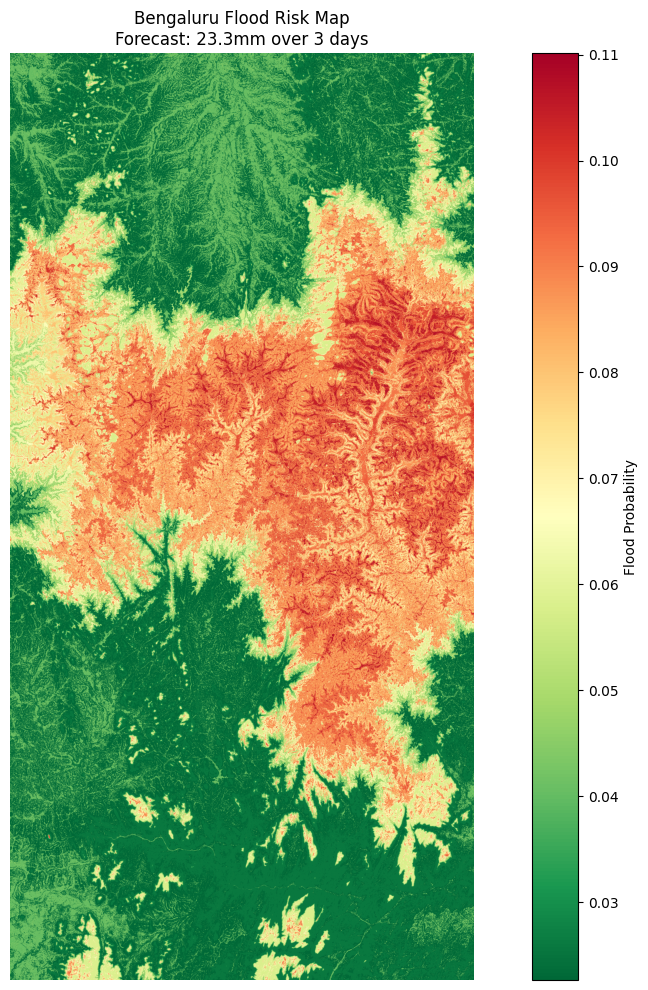

In [ ]:
plt.figure(figsize=(12, 10))
plt.imshow(flood_risk_map, cmap='RdYlGn_r')
plt.colorbar(label='Flood Probability')
plt.title(f'Bengaluru Flood Risk Map\nForecast: {total:.1f}mm over 3 days')
plt.axis('off')
plt.tight_layout()
plt.savefig('flood_risk_forecast.png', dpi=150)
plt.show()

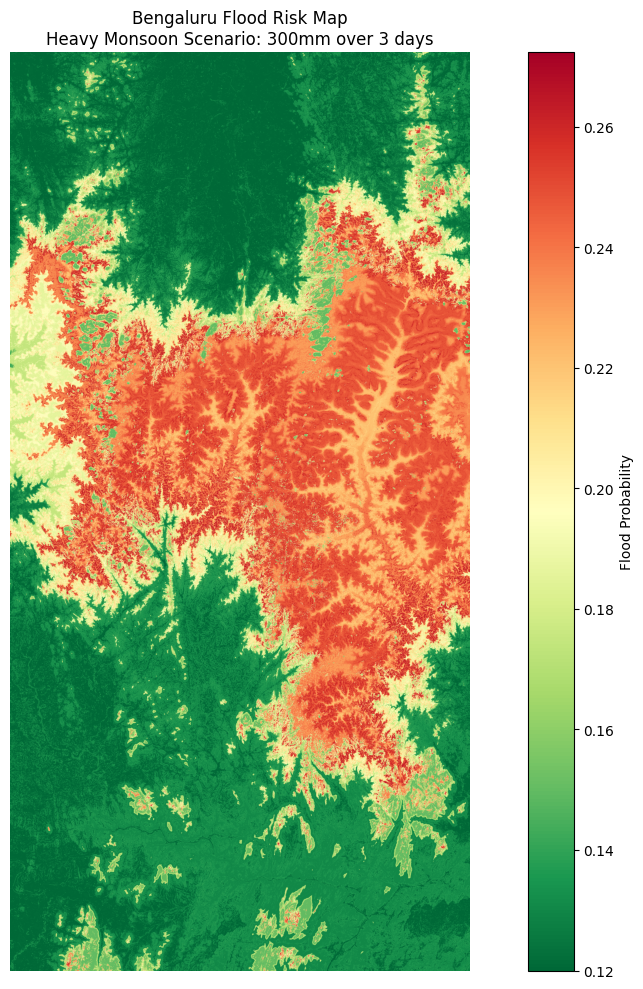

In [ ]:
forecast_grid_heavy = pd.DataFrame({
    'elevation':      elevation_grid.flatten(),
    'max_rainfall':   150,
    'mean_rainfall':  50,
    'total_rainfall': 300,
    'slope':          slope.flatten()
})

flood_probability_heavy = rf_model.predict_proba(forecast_grid_heavy)[:, 1]
flood_risk_heavy = flood_probability_heavy.reshape(target_height, target_width)

plt.figure(figsize=(12, 10))
plt.imshow(flood_risk_heavy, cmap='RdYlGn_r')
plt.colorbar(label='Flood Probability')
plt.title('Bengaluru Flood Risk Map\nHeavy Monsoon Scenario: 300mm over 3 days')
plt.axis('off')
plt.tight_layout()
plt.savefig('flood_risk_heavy.png', dpi=150)
plt.show()

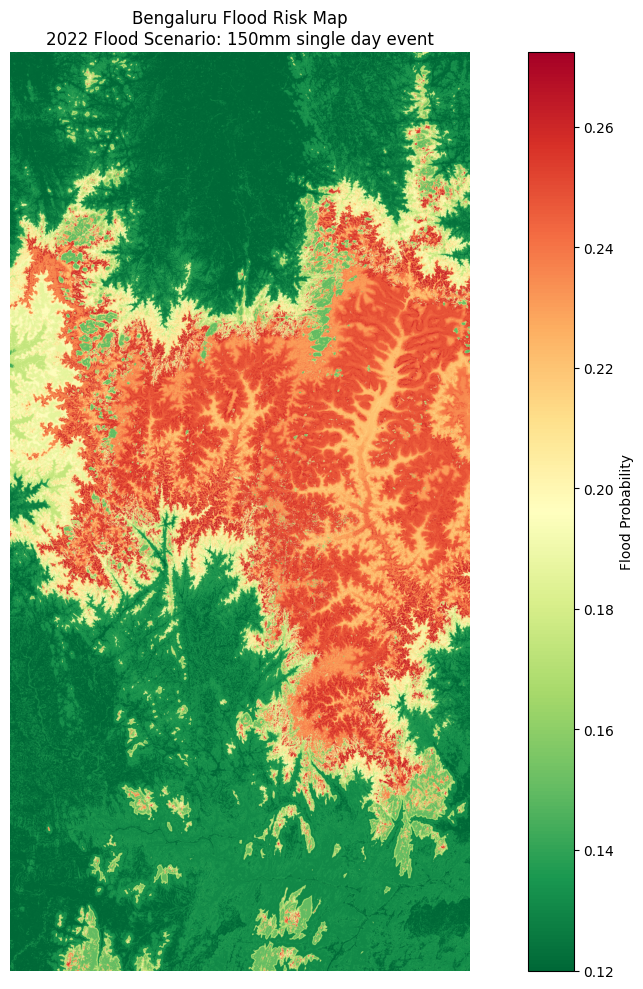

In [ ]:
forecast_grid_2022 = pd.DataFrame({
    'elevation':      elevation_grid.flatten(),
    'max_rainfall':   150,
    'mean_rainfall':  30,
    'total_rainfall': 150,
    'slope':          slope.flatten()
})

flood_probability_2022 = rf_model.predict_proba(forecast_grid_2022)[:, 1]
flood_risk_2022 = flood_probability_2022.reshape(target_height, target_width)

plt.figure(figsize=(12, 10))
plt.imshow(flood_risk_2022, cmap='RdYlGn_r')
plt.colorbar(label='Flood Probability')
plt.title('Bengaluru Flood Risk Map\n2022 Flood Scenario: 150mm single day event')
plt.axis('off')
plt.tight_layout()
plt.savefig('flood_risk_2022.png', dpi=150)
plt.show()

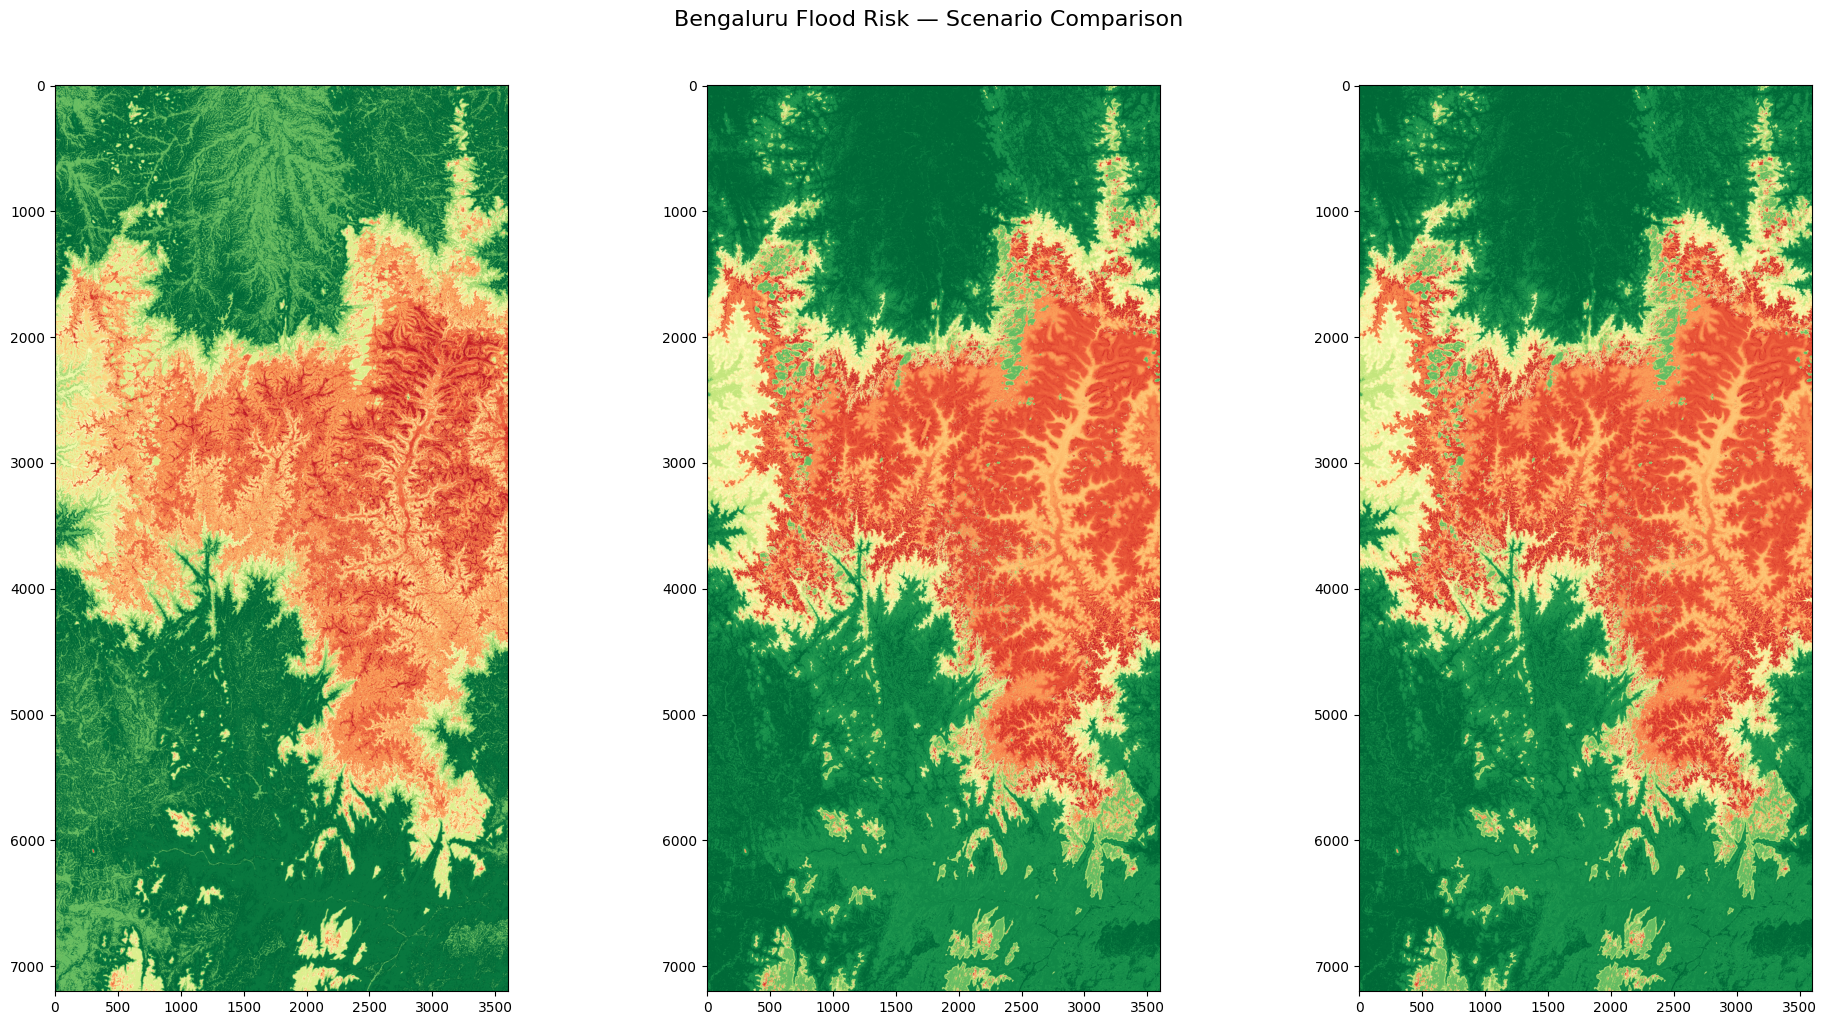

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))

axes[0].imshow(flood_risk_map, cmap='RdYlGn_r')
axes[1].imshow(flood_risk_2022, cmap='RdYlGn_r')
axes[2].imshow(flood_risk_heavy, cmap='RdYlGn_r')

plt.suptitle('Bengaluru Flood Risk — Scenario Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
xmin = elevation_transform[2]
x_pixel_size = elevation_transform[0]
xmax = xmin + (target_width * x_pixel_size)
ymax = elevation_transform[5]
y_pixel_size = elevation_transform[4]
ymin = ymax + (target_height * y_pixel_size)

In [27]:
from geopy.geocoders import Nominatim
import time

# Bengaluru bounding box
BLR_LAT_MIN, BLR_LAT_MAX = 12.83, 13.18
BLR_LON_MIN, BLR_LON_MAX = 77.46, 77.78

# clip to city bounds
row_min = int((ymax - BLR_LAT_MAX) / abs(y_pixel_size))
row_max = int((ymax - BLR_LAT_MIN) / abs(y_pixel_size))
col_min = int((BLR_LON_MIN - xmin) / x_pixel_size)
col_max = int((BLR_LON_MAX - xmin) / x_pixel_size)

# choose scenario and threshold
target_map = flood_risk_heavy   # or flood_risk_map / flood_risk_2022
threshold  = 0.20               # recall-biased for flood warnings

city_map = target_map[row_min:row_max, col_min:col_max]

# find high risk pixels within city
high_risk_rows, high_risk_cols = np.where(city_map > threshold)
print(f"High risk pixels within Bengaluru: {len(high_risk_rows)}")

# convert to lat/lon
high_risk_lons = xmin + (col_min + high_risk_cols) * x_pixel_size
high_risk_lats = ymax + (row_min + high_risk_rows) * y_pixel_size

# sample ~80 points
step = max(1, len(high_risk_rows) // 80)
sampled_lats = high_risk_lats[::step]
sampled_lons = high_risk_lons[::step]

# geocode
geolocator = Nominatim(user_agent="flood_risk_bengaluru")
locations = set()

print("Geocoding... (~2 minutes)")
for i, (lat, lon) in enumerate(zip(sampled_lats, sampled_lons)):
    try:
        loc = geolocator.reverse(f"{lat}, {lon}", language='en', timeout=10)
        if loc:
            addr = loc.raw.get('address', {})
            area = (addr.get('neighbourhood') or
                    addr.get('suburb') or
                    addr.get('quarter') or
                    addr.get('residential') or
                    addr.get('village') or
                    addr.get('town') or
                    addr.get('county', ''))
            if area and area.isascii():
                locations.add(area)
        time.sleep(1)
    except:
        continue
    if i % 10 == 0:
        print(f"  {i}/{len(sampled_lats)} done...")

print(f"\n===== HIGH FLOOD RISK AREAS (threshold={threshold}) =====")
for loc in sorted(locations):
    print(f"  - {loc}")
print(f"\nTotal unique areas: {len(locations)}")

High risk pixels within Bengaluru: 1320470
Geocoding... (~2 minutes)
  0/81 done...
  10/81 done...
  20/81 done...
  30/81 done...
  40/81 done...
  50/81 done...
  60/81 done...
  70/81 done...
  80/81 done...

===== HIGH FLOOD RISK AREAS (threshold=0.2) =====
  - Abdul Kalam Nagar
  - Addiganahalli
  - Aduru
  - Aivarakandapura
  - Akash Ward
  - Anjanapura
  - Arkavathy Layout 19th Block
  - Arkavathy Layout 20th Block
  - BEL Colony
  - BOOHBCS Layout
  - Balaji Layout Phase 2
  - Bande Kodigehalli
  - Belathur
  - Canara Bank Layout
  - Chaithanya Samarpan
  - Chamarajapete
  - Chikka Banavara
  - Chowdeshwari Nagar
  - D Group Employees Layout
  - Dodda Nekkundi
  - Dr. Shivaram Karanth Layout
  - EPIP Zone
  - Electronic City
  - Electronics City Phase 1
  - Gandhi Bazaar
  - Gangavara Chaudappanahalli
  - Gangodanahalli
  - Goripalya
  - Gundur
  - Guni Agrahara
  - Hesaraghatta
  - Hosahalli
  - Hunasamaranahalli
  - Hurali Chikkanahalli
  - Huvinayakanahalli
  - Jagadish Nag